# Network Intrusion Detection System using NSL-KDD Dataset
This notebook implements a machine learning-based intrusion detection system using the NSL-KDD dataset.

In [3]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Import machine learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                           precision_score, recall_score, f1_score, roc_auc_score, roc_curve)
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
import joblib

# Set style for better visualizations
plt.style.use('ggplot')  # Changed from 'seaborn' to 'ggplot', a valid Matplotlib style
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Define column names for NSL-KDD dataset
column_names = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'class', 'difficulty'
]

# Load the dataset
try:
    df = pd.read_csv('KDDTrain+.txt', names=column_names)
    print(f"Dataset loaded successfully!")
    print(f"Dataset shape: {df.shape}")
except FileNotFoundError:
    print("Dataset file not found. Please download KDDTrain+.txt from:")
    print("https://github.com/jmnwong/NSL-KDD-Dataset")
    # Create a sample dataset for demonstration
    np.random.seed(42)
    n_samples = 1000
    df = pd.DataFrame({
        col: np.random.randn(n_samples) if col not in ['protocol_type', 'service', 'flag', 'class', 'difficulty'] 
        else np.random.choice(['tcp', 'udp', 'icmp'], n_samples) if col == 'protocol_type'
        else np.random.choice(['http', 'ftp', 'smtp'], n_samples) if col == 'service'
        else np.random.choice(['SF', 'S0', 'REJ'], n_samples) if col == 'flag'
        else np.random.choice(['normal', 'smurf', 'neptune', 'back'], n_samples) if col == 'class'
        else np.random.randint(1, 22, n_samples)
        for col in column_names
    })
    print("Using sample dataset for demonstration")

# Remove difficulty column as it's not needed for classification
if 'difficulty' in df.columns:
    df = df.drop('difficulty', axis=1)

print(f"Final dataset shape: {df.shape}")

Dataset loaded successfully!
Dataset shape: (125973, 43)
Final dataset shape: (125973, 42)


2. DATA VISUALIZATION AND EXPLORATION
Sample Data (First 5 rows):
   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_srv_count  \
0               0       0    0  ...                  25   
1               0       0    0  ...                   1   
2               0       0    0  ...                  26   
3               0       0    0  ...                 255   
4               0       0    0  ...                 255   

   dst_host_same_srv_rate  dst_host_diff_srv_rate  \
0                    0.17                    0.03   
1                    0.00               

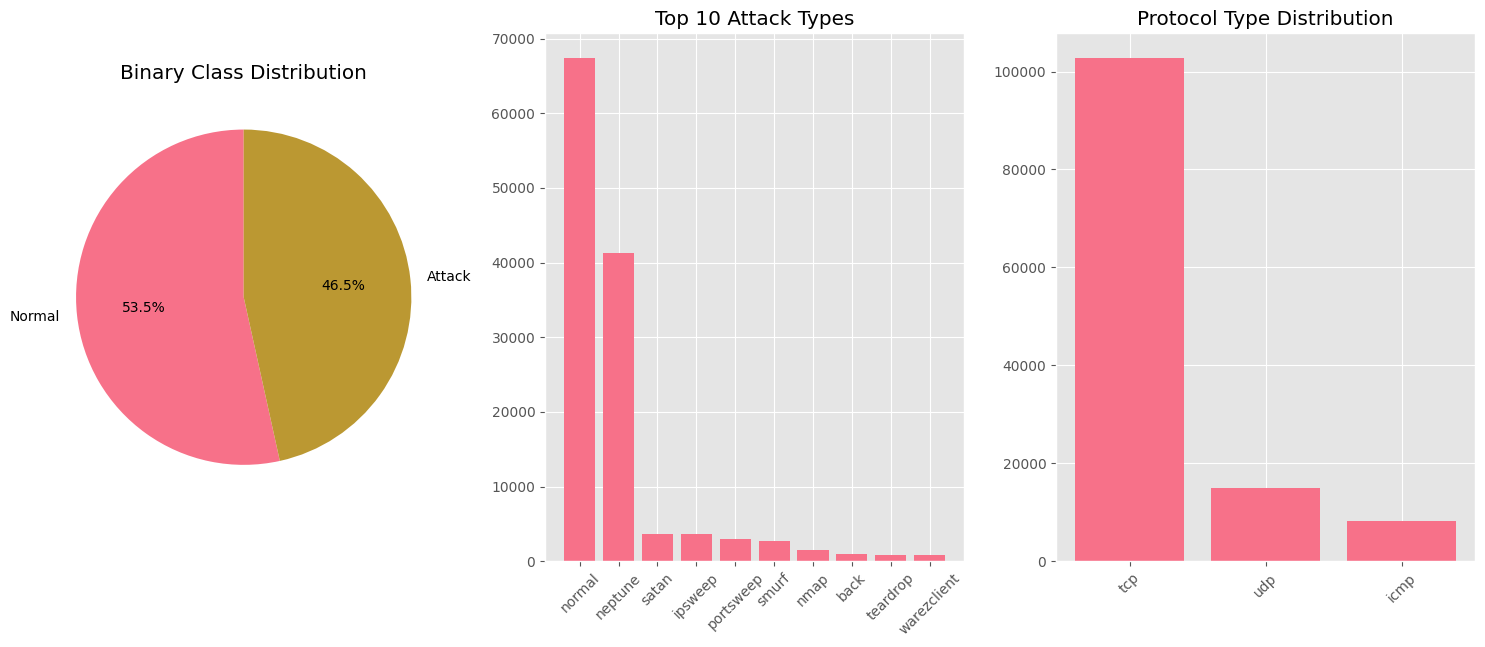

In [5]:
# Data visualization and exploration
print("2. DATA VISUALIZATION AND EXPLORATION")

# Print 5 rows for sanity check
print("Sample Data (First 5 rows):")
print(df.head())
print(f"\nDataset Info:")
print(f"Shape: {df.shape}")
print(f"Features: {df.shape[1]-1}")
print(f"Samples: {df.shape[0]}")

# Check data types
print(f"\nData Types:")
print(df.dtypes.value_counts())

# Create binary classification labels
df['binary_class'] = df['class'].apply(lambda x: 'Normal' if x == 'normal' else 'Attack')

# Class distribution
plt.figure(figsize=(15, 12))

# Class distribution
plt.subplot(2, 3, 1)
class_counts = df['binary_class'].value_counts()
plt.pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Binary Class Distribution')

# Original class distribution
plt.subplot(2, 3, 2)
original_classes = df['class'].value_counts().head(10)
plt.bar(range(len(original_classes)), original_classes.values)
plt.title('Top 10 Attack Types')
plt.xticks(range(len(original_classes)), original_classes.index, rotation=45)

# Protocol type distribution
plt.subplot(2, 3, 3)
protocol_counts = df['protocol_type'].value_counts()
plt.bar(protocol_counts.index, protocol_counts.values)
plt.title('Protocol Type Distribution')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()